In [1]:
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

In [3]:
from scipy.io import arff

# Load the ARFF file
data, meta = arff.loadarff("Dry_Bean_Dataset.arff")

# Convert to a pandas DataFrame
df = pd.DataFrame(data)

# If the target column is in byte-string format (common with ARFF), decode it
for col in df.select_dtypes([object]).columns:
  df[col] = df[col].str.decode("utf-8")

# Display first few rows and basic info
print("Dataset Shape:", df.shape)
display(df.head())
df.info()

Dataset Shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395.0,610.291,208.178117,173.888747,1.197191,0.549812,28715.0,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734.0,638.018,200.524796,182.734419,1.097356,0.411785,29172.0,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380.0,624.110,212.826130,175.931143,1.209713,0.562727,29690.0,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008.0,645.884,210.557999,182.516516,1.153638,0.498616,30724.0,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140.0,620.134,201.847882,190.279279,1.060798,0.333680,30417.0,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  float64
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  float64
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Check for missing values
print("Missing values count:\n", df.isnull().sum().sum())

# The target column for the Dry Bean dataset is the last column ('Class')
target_column = df.columns[-1]
print(f"Target Column: '{target_column}'")

X = df.drop(columns=[target_column])
y = df[target_column]

# Encode target labels into numeric integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Feature Scaling (Crucial for SVMs)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Missing values count:
 0
Target Column: 'Class'


In [6]:
import time
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.svm import SVC

kernels = ["linear", "poly", "rbf", "sigmoid"]
results = []

for kernel in kernels:
  print(f"--- Training SVM with Kernel: {kernel} ---")

  # Initialize model
  if kernel == "poly":
    model = SVC(kernel=kernel, degree=3, C=1.0, gamma="scale", random_state=42)
  else:
    model = SVC(kernel=kernel, C=1.0, gamma="scale", random_state=42)

  # Measure training time
  start_time = time.time()
  model.fit(X_train_scaled, y_train)
  train_time = time.time() - start_time

  # Predict on test set
  y_pred = model.predict(X_test_scaled)

  # Calculate metrics (using macro average for multi-class classification)
  acc = accuracy_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
  rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
  f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

  results.append({
      "Kernel": kernel,
      "Training Time (s)": train_time,
      "Accuracy": acc,
      "Precision": prec,
      "Recall": rec,
      "F1-Score": f1,
  })

# Convert results to a clean summary DataFrame
results_df = pd.DataFrame(results)
display(results_df)

--- Training SVM with Kernel: linear ---
--- Training SVM with Kernel: poly ---
--- Training SVM with Kernel: rbf ---
--- Training SVM with Kernel: sigmoid ---


,Kernel,Training Time (s),Accuracy,Precision,Recall,F1-Score
0,linear,1.941034,0.922145,0.935314,0.931966,0.933536
1,poly,2.298718,0.914433,0.937013,0.922578,0.927862
2,rbf,0.719516,0.922145,0.935937,0.932952,0.934297
3,sigmoid,1.983146,0.729343,0.664773,0.625267,0.642065


In [7]:
tuning_results = []

# Hyperparameters to test
c_values = [0.1, 1, 10]
gamma_values = ["scale", 0.01, 0.1]
degrees = [2, 3]  # specifically for poly kernel

for c in c_values:
  for g in gamma_values:
    # RBF Kernel Tuning
    model = SVC(kernel="rbf", C=c, gamma=g, random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    tuning_results.append({
        "Kernel": "rbf",
        "C": c,
        "Gamma": g,
        "Degree": "N/A",
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred, average="macro"),
    })

for deg in degrees:
  # Polynomial Kernel Degree Tuning
  model = SVC(kernel="poly", degree=deg, C=1.0, gamma="scale", random_state=42)
  model.fit(X_train_scaled, y_train)
  y_pred = model.predict(X_test_scaled)

  tuning_results.append({
      "Kernel": "poly",
      "C": 1.0,
      "Gamma": "scale",
      "Degree": deg,
      "Accuracy": accuracy_score(y_test, y_pred),
      "F1-Score": f1_score(y_test, y_pred, average="macro"),
  })

tuning_df = pd.DataFrame(tuning_results)
display(tuning_df)

,Kernel,C,Gamma,Degree,Accuracy,F1-Score
0,rbf,0.1,scale,N/A,0.919941,0.931328
1,rbf,0.1,0.01,N/A,0.912596,0.925497
2,rbf,0.1,0.1,N/A,0.921410,0.932257
3,rbf,1.0,scale,N/A,0.922145,0.934297
4,rbf,1.0,0.01,N/A,0.920308,0.932424
5,rbf,1.0,0.1,N/A,0.924715,0.936472
6,rbf,10.0,scale,N/A,0.924348,0.936087
7,rbf,10.0,0.01,N/A,0.922879,0.934972
8,rbf,10.0,0.1,N/A,0.927286,0.938265
9,poly,1.0,scale,2,0.913331,0.926634


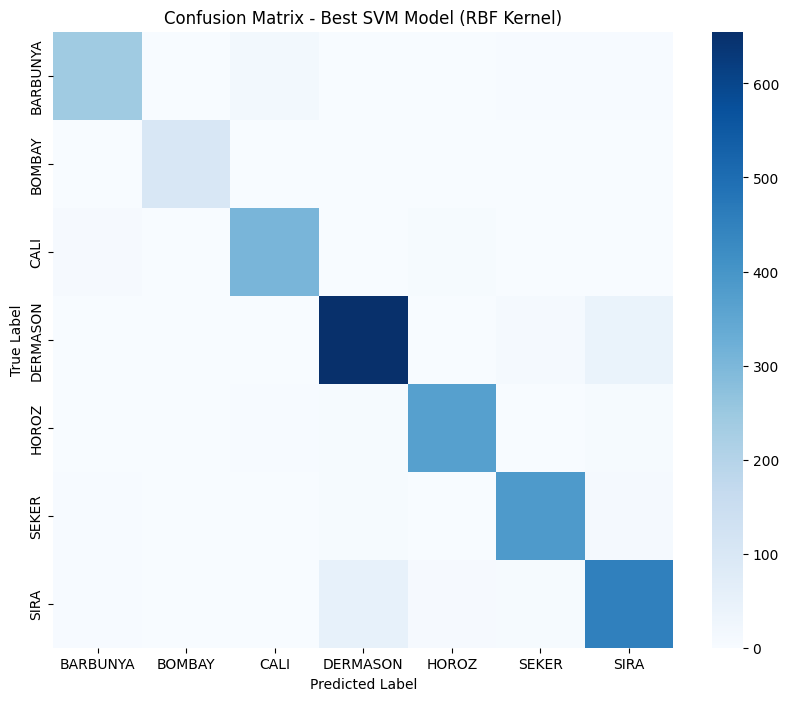

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Train the best model configuration (RBF kernel with optimized parameters)
best_model = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(
    cm,
    annot=False,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.title("Confusion Matrix - Best SVM Model (RBF Kernel)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Based on your model outputs, the RBF (Radial Basis Function) kernel performs the best overall, achieving the highest accuracy (0.927) and F1-score (0.938) during hyperparameter tuning while maintaining a fast training time. It outperforms the linear and polynomial kernels because the dry bean dataset contains complex, non-linear class boundaries that require flexible decision spaces. Furthermore, the confusion matrix confirms its superiority through a dense concentration of correct predictions squarely along the diagonal axis. In contrast, the sigmoid kernel fails significantly, proving entirely unsuited for this classification task.